In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Apr 20 10:16:41 2022
Modified May 2026

@author: Daniel Edwin Hill, adapted by Martin Slawski
"""
#credit given to Dr. Jason Brownlee from https://machinelearningmastery.com/how-to-develop-a-generative-adversarial-network-for-a-cifar-10-small-object-photographs-from-scratch/

'\nCreated on Wed Apr 20 10:16:41 2022\nModified May 2026\n\n@author: Daniel Edwin Hill, adapted by Martin Slawski\n'

In [2]:
import os
print(os.path.expanduser('~/.keras/datasets/'))

/Users/martinslawski/.keras/datasets/


In [3]:
# example of a dcgan on cifar10
from numpy import sqrt
import random
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import vstack
from numpy.random import randn
from numpy.random import randint
import numpy as np
from keras.src import backend
from tensorflow.keras.datasets.cifar10 import load_data
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import get_file
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dropout
from matplotlib import pyplot

In [4]:
def display_images(n, data):
    img_ind = random.sample(range(0,len(data)-1), int(n**2))
    for i in range(int(n**2)):
        pyplot.subplot(int(n), int(n), 1+i)
        
        pyplot.axis('off')
        
        pyplot.imshow(data[img_ind[i]])
        
    pyplot.show()

In [5]:
# define the standalone discriminator model
def define_discriminator(in_shape=(32,32,3)):
    model = Sequential()
    model.add(Input(shape=in_shape)) 
	# normal
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# downsample
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# downsample
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# downsample
    model.add(Conv2D(256, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# classifier
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
	# compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    #model.summary()
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [6]:
# foundation for 4x4 image
	#n_nodes = 256 * 4 * 4
	#model.add(Dense(n_nodes, input_dim=latent_dim))

# define the standalone generator model
def define_generator(latent_dim):
    n_nodes = 256 * 4 * 4
    model = Sequential()
    model.add(Input(shape=(latent_dim,))) 
    model.add(Dense(n_nodes))#, input_dim=latent_dim))
    #model = Sequential([
    #Input(shape=(latent_dim,)),  # Explicitly define the input shape here
    #Dense(n_nodes, activation='relu'),
    #Dense(1)])
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Reshape((4, 4, 256)))
	# upsample to 8x8
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# upsample to 16x16
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# upsample to 32x32
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(negative_slope=0.2))
	# output layer
    model.add(Conv2D(3, (3,3), activation='tanh', padding='same'))
    #model.summary()
    return model

In [7]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):
	# make weights in the discriminator not trainable
    d_model.trainable = False
	# connect them
    model = Sequential()
	# add generator
    model.add(g_model)
	# add the discriminator
    model.add(d_model)
	# compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    #model.summary()
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

In [8]:
# load and prepare cifar10 training images
def load_real_samples():
	# load cifar10 dataset
	(trainX, _), (_, _) = load_data()
	# convert from unsigned ints to floats
	X = trainX.astype('float32')
	# scale from [0,255] to [-1,1]
	X = (X - 127.5) / 127.5
	return X

In [9]:
import _pickle as cPickle


def load_batch(fpath, label_key="labels"):
    """Internal utility for parsing CIFAR data.

    Args:
        fpath: path the file to parse.
        label_key: key for label data in the retrieve
            dictionary.

    Returns:
        A tuple `(data, labels)`.
    """
    with open(fpath, "rb") as f:
        d = cPickle.load(f, encoding="bytes")
        # decode utf8
        d_decoded = {}
        for k, v in d.items():
            d_decoded[k.decode("utf8")] = v
        d = d_decoded
    data = d["data"]
    labels = d[label_key]

    data = data.reshape(data.shape[0], 3, 32, 32)
    return data, labels

In [10]:
# select real samples
def generate_real_samples(dataset, n_samples):
	# choose random instances
	ix = randint(0, dataset.shape[0], n_samples)
	# retrieve selected images
	X = dataset[ix]
	# generate 'real' class labels (1)
	y = ones((n_samples, 1))
	return X, y

In [11]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
	# generate points in the latent space
	x_input = randn(latent_dim * n_samples)
	# reshape into a batch of inputs for the network
	x_input = x_input.reshape(n_samples, latent_dim)
	return x_input

In [12]:
# use the generator to generate n fake examples, with class labels
def generate_fake_samples(g_model, latent_dim, n_samples):
	# generate points in latent space
	x_input = generate_latent_points(latent_dim, n_samples)
	# predict outputs
	X = g_model.predict(x_input)
	# create 'fake' class labels (0)
	y = zeros((n_samples, 1))
	return X, y

In [13]:
# create and save a plot of generated images
def save_plot(examples, epoch, n=7):
	# scale from [-1,1] to [0,1]
	examples = (examples + 1) / 2.0
	# plot images
	for i in range(n * n):
		# define subplot
		pyplot.subplot(n, n, 1 + i)
		# turn off axis
		pyplot.axis('off')
		# plot raw pixel data
		pyplot.imshow(examples[i])
	# save plot to file
	filename = 'generated_plot_e%03d.png' % (epoch+1)
	pyplot.savefig(filename)
	pyplot.close()

In [14]:
# evaluate the discriminator, plot generated images, save generator model
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=150):
	# prepare real samples
	X_real, y_real = generate_real_samples(dataset, n_samples)
	# evaluate discriminator on real examples
	_, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
	# prepare fake examples
	x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
	# evaluate discriminator on fake examples
	_, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
	# summarize discriminator performance
	print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))
	# save plot
	save_plot(x_fake, epoch)
	# save the generator model tile file
	filename = 'generator_model_%03d.h5' % (epoch+1)
	g_model.save(filename)

In [26]:
# train the generator and discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=200, n_batch=128):
	bat_per_epo = int(dataset.shape[0] / n_batch)
	half_batch = int(n_batch / 2)
	# manually enumerate epochs
	for i in range(n_epochs):
		# enumerate batches over the training set
		for j in range(bat_per_epo):
			# get randomly selected 'real' samples
			X_real, y_real = generate_real_samples(dataset, half_batch)
			# update discriminator model weights
			d_loss1, _ = d_model.train_on_batch(X_real, y_real)
			# generate 'fake' examples
			X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			# update discriminator model weights
			d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)
			# prepare points in latent space as input for the generator
			X_gan = generate_latent_points(latent_dim, n_batch)
			# create inverted labels for the fake samples
			y_gan = ones((n_batch, 1))
			# update the generator via the discriminator's error
			g_loss = gan_model.train_on_batch(X_gan, y_gan)
			# summarize loss on this batch
			print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
				(i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))
		# evaluate the model performance, sometimes
		if (i+1) % 10 == 0:
			summarize_performance(i, g_model, d_model, dataset, latent_dim)

In [ ]:
#
# size of the latent space
latent_dim = 100
# create the discriminator
d_model = define_discriminator()
# create the generator
g_model = define_generator(latent_dim)
# create the gan
gan_model = define_gan(g_model, d_model)
# load image data -- this does not run on my machine, but if it works for yours, you can skip the next block
#dataset = load_real_samples()

In [17]:
# load CIFAR-10 images
num_train_samples = 50000

x_train = np.empty((num_train_samples, 3, 32, 32), dtype="uint8")
y_train = np.empty((num_train_samples,), dtype="uint8")

# modify the filepath as needed
path = '/Users/martinslawski/.keras/datasets/cifar-10-batches-py_extracted/cifar-10-batches-py/'

for i in range(1, 6):
    fpath = os.path.join(path, "data_batch_" + str(i))
    (x_train[(i - 1) * 10000 : i * 10000, :, :, :], y_train[(i - 1) * 10000 : i * 10000],) = load_batch(fpath)

fpath = os.path.join(path, "test_batch")
x_test, y_test = load_batch(fpath)

y_train = np.reshape(y_train, (len(y_train), 1))
y_test = np.reshape(y_test, (len(y_test), 1))

if backend.image_data_format() == "channels_last":
    x_train = x_train.transpose(0, 2, 3, 1)
    x_test = x_test.transpose(0, 2, 3, 1)
    x_test = x_test.astype(x_train.dtype)
    y_test = y_test.astype(y_train.dtype)

In [18]:
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

In [19]:
dataset = x_train
dataset = dataset.astype('float32')
dataset = (dataset - 127.5) / 127.5

In [ ]:
# train model
train(g_model, d_model, gan_model, dataset, latent_dim)

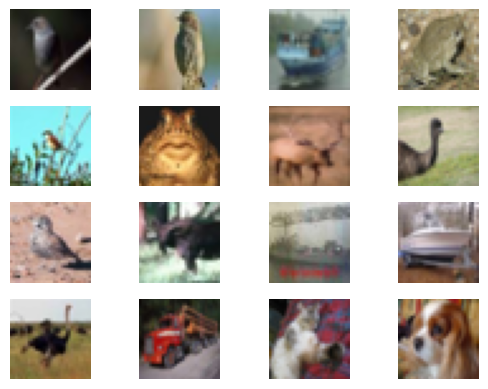

In [58]:
display_images(4, x_train)

In [53]:
tmp = generate_fake_samples(g_model, 100, 20)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [123]:
tmp = tmp[0]

In [ ]:
display_images(4,  (tmp + 1.0)/2.0)